In [304]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

### 1D nodal --> modal

In [305]:
from numpy.polynomial.legendre import leggauss
from scipy.special import eval_legendre

def reference_nodes_equispaced_1d(p):
    if not isinstance(p, int):
        raise TypeError("p must be an integer.")
    if p < 0:
        raise ValueError("p must be nonnegative.")

    if p == 0:
        return np.array([0.0], dtype=float)

    return np.linspace(-1.0, 1.0, p + 1, dtype=float)

def eval_orthonormal_legendre_1d(x, p):
    """
    Evaluate orthonormal Legendre basis l_0,...,l_p at points x.
    
    Returns array of shape (p+1, len(x)).
    """
    x = np.asarray(x)
    out = np.zeros((p + 1, x.size))

    for n in range(p + 1):
        out[n, :] = np.sqrt((2*n + 1)/2.0) * eval_legendre(n, x)

    return out

def vandermonde_1d(nodes, p):
    """
    Build 1D Vandermonde matrix V[i,m] = phi_m(nodes[i]).
    """
    L = eval_orthonormal_legendre_1d(nodes, p)   # shape (p+1, p+1), modes x nodes
    V = L.T                    # shape (nodes, modes)
    Vinv = np.linalg.inv(V)
    return V, Vinv

def nodal_to_modal_1d_block(u_block, Vinv):
    """
    Convert one 1D local nodal block to modal coefficients.
    """
    u_block = np.asarray(u_block, dtype=float)
    return Vinv @ u_block

def modal_to_nodal_1d_block(a_block, V):
    a_block = np.asarray(a_block, dtype=float)
    return V @ a_block

def nodal_data_to_modal_1d(Unode, p):
    """
    Convert 1D elementwise nodal data to modal coefficients.
    """
    order = p + 1
    nodes = reference_nodes_equispaced_1d(p=p)
    V, Vinv = vandermonde_1d(nodes, p=p)
    
    # Expected Unode.shape: (Kx, order)
    Unode = np.asarray(Unode, dtype=float)
    Kx = Unode.shape[0]
    coeffs = np.zeros((Kx, order), dtype=float)
    for e in range(Kx):
        coeffs[e, :] = nodal_to_modal_1d_block(Unode[e, :], Vinv)
    
    return coeffs, nodes, V, Vinv
        
def reconstruct_nodal_data_1d(coeffs, V):
    """
    coeffs: shape (Kx, order)
    returns nodal values of shape (Kx, order)
    """
    Kx, order = coeffs.shape
    Urec = np.zeros((Kx, order), dtype=float)
    for e in range(Kx):
        Urec[e, :] = modal_to_nodal_1d_block(coeffs[e, :], V)
    return Urec
    


In [306]:
def eval_dg_modal_1d(x, coeffs, x_edges, p, fill_value=0.0):
    """
    Evaluate a 1D DG modal field at arbitrary physical points x
    """
    x = np.asarray(x, dtype=float)
    xf = x.ravel()
    
    Kx = coeffs.shape[0]
    xmin = x_edges[0]
    xmax = x_edges[-1]
    
    u = np.full(xf.shape, fill_value, dtype=float)
    
    for k in range(xf.size):
        xx = xf[k]
        
        # outside domain
        if (xx < xmin) or (xx > xmax):
            continue
        
        # element index
        e = np.searchsorted(x_edges, xx, side="right") - 1
        if e == Kx:
            e = Kx - 1      # convention of right open boundary --> right last eval point belongs to rightmost element
        # e = int(np.clip(e, 0, Kx - 1))
        
        # element bounds
        x0 = x_edges[e]
        x1 = x_edges[e + 1]
        
        # map to reference interval [-1,1]
        r = 2.0 * (xx - x0) / (x1 - x0) - 1.0
        # r = np.clip(r, -1.0, 1.0)
        
        # basis values at r
        l = eval_orthonormal_legendre_1d(np.array([r]), p)[:, 0]
        
        # modal expansion
        u[k] = np.dot(coeffs[e, :], l)
    
    return u.reshape(x.shape)

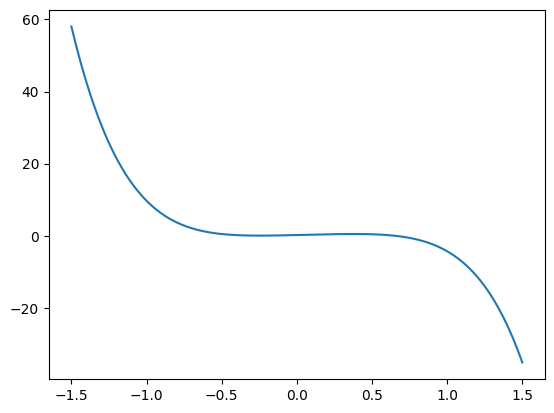

In [307]:
# Test function
# def exact_func(x, n=2):
#     """
#     returns poly as: x^n + x^(n-1) + ... + x^2 + x 
#     """
#     poly = np.zeros_like(x, dtype=float)
#     for k in range(1, n+1):
#         poly += x**k
#     return poly
xleft, xright = -1.5, 1.5
def exact_func(x):
    # return np.sin(np.pi * x)
    # return -(np.exp(-30 * (x - 0.35)**2) + 0.15 * np.sin(2*np.pi*x))
    # return (x-xleft)*(x-xright)*x
    return -5*x**5 + 2*x**4 - 3*x**3 + 0.5*x**2 + x + 0.2

# def exact_func(x):
#     return x**3
    
        
# DG stuff
Kx = 24     # nr elements
deg = 4     # DG basis degree
order = deg + 1

# mesh
dx = (xright - xleft) / Kx
xmesh = np.linspace(xleft, xright, Kx + 1)

# Nodes
Nodes = np.linspace(-1.0, 1.0, order)
left_endpoints = xmesh[:-1]
y = left_endpoints[:, None] + 0.5 * dx * (Nodes[None, :] + 1.0)


# fine grid
grid_fine = np.linspace(xleft, xright, 2001)
plt.plot(grid_fine, exact_func(grid_fine))

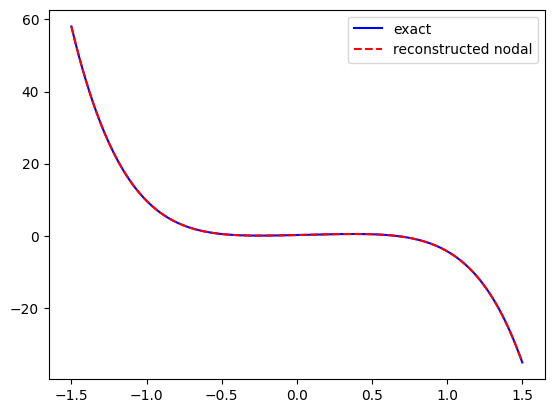

np.float64(2.842170943040401e-14)

In [308]:
# create nodal (noisy or not) coefficients
Unode = exact_func(y) #+ np.random.randn(*y.shape) * dx**(deg + 1)

coeffs_1d, nodes, V, Vinv = nodal_data_to_modal_1d(
    Unode, 
    p=deg
)

Urec = reconstruct_nodal_data_1d(coeffs_1d, V)

# compare exact and evaluated nodal
plt.plot(grid_fine, exact_func(grid_fine), "b-", label="exact")
plt.plot(y.ravel(), Urec.ravel(), "r--", label="reconstructed nodal")
plt.legend()
plt.show()

np.max(np.abs(Urec - Unode))

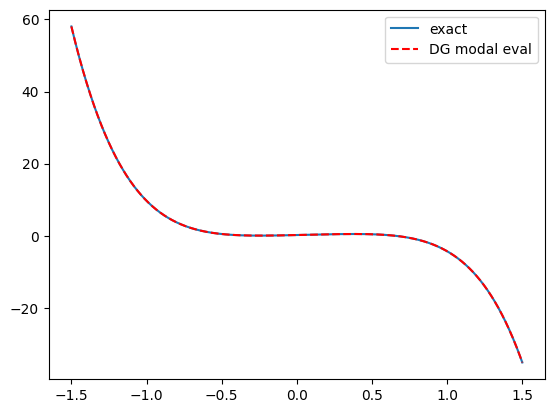

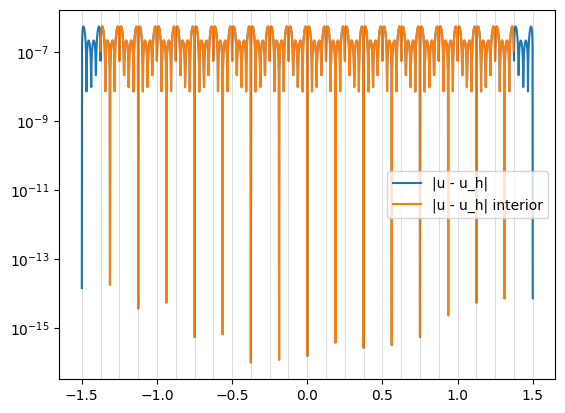

In [309]:
# compare inter element values

u_eval = eval_dg_modal_1d(
    x=grid_fine,
    coeffs=coeffs_1d,
    x_edges=xmesh,
    p=deg
)

u_exact_fine = exact_func(grid_fine)

plt.plot(grid_fine, u_exact_fine, label="exact")
plt.plot(grid_fine, u_eval, "r--", label="DG modal eval")
plt.legend()
plt.show()

# difference / error
eps = 1e-16
plt.semilogy(grid_fine, np.abs(u_exact_fine - u_eval) + eps, label="|u - u_h|")
mask = (grid_fine > xleft + dx) & (grid_fine < xright - dx)

plt.semilogy(grid_fine[mask], np.abs(u_exact_fine[mask] - u_eval[mask]) + eps, label="|u - u_h| interior")
for xe in xmesh:
    plt.axvline(xe, color='k', linewidth=0.5, alpha=0.2)
plt.legend()
plt.show()

### SIAC

In [310]:
from src.siac_modal import grab_integrals, siac_cgam
def eval_siac_1d_on_grid(x, coeffs, x_edges, p, moments, BSorder, fill_value=0.0):
    """
    Evaluate 1D SIAC-filtered DG field at arbitrary physical points x.
    """
    BSknots = np.linspace(-BSorder/2, BSorder/2, BSorder + 1)
    BSsupport = np.array([np.floor(BSknots[0]), np.ceil(BSknots[-1])], dtype=int)
    BSlen = BSsupport[1] - BSsupport[0] + 1
    
    kernellength = 2 * int(np.ceil((moments + BSorder) / 2)) + 1
    halfker = int(np.ceil((moments + BSorder) / 2))
    
    cgam = siac_cgam(moments, BSorder)
    
    
    x = np.asarray(x, dtype=float)
    xf = x.ravel()

    Kx, order = coeffs.shape
    xmin = x_edges[0]
    xmax = x_edges[-1]

    pad = halfker + 1
    coeffs_pad = np.zeros((Kx + 2 * pad, order), dtype=float)
    coeffs_pad[pad:pad + Kx, :] = coeffs

    ustar = np.full(xf.shape, fill_value, dtype=float)

    for k, xx in enumerate(xf):
        if (xx < xmin) or (xx > xmax):
            continue

        # target element
        e = np.searchsorted(x_edges, xx, side="right") - 1
        e = int(np.clip(e, 0, Kx - 1))

        x0 = x_edges[e]
        x1 = x_edges[e + 1]

        # local coordinate in target element
        zeta = 2.0 * (xx - x0) / (x1 - x0) - 1.0
        zeta = np.clip(zeta, -1.0, 1.0)

        # integrals for this single local point
        BSInt_pt = grab_integrals(
            eval_nodes=np.array([zeta]),
            p=p,
            BSorder=BSorder,
            BSsupport=BSsupport
        )   # shape (order, BSlen, 1)

        SIAC_pt = np.zeros((order, kernellength), dtype=float)
        for igam in range(moments + 1):
            SIAC_pt[:, igam:igam + BSlen] += cgam[igam] * BSInt_pt[:, :, 0]

        center = e + pad
        stencil = coeffs_pad[center - halfker:center + halfker + 1, :]   # (kernellength, order)

        ustar[k] = np.sum(SIAC_pt * stencil.T)

    return ustar.reshape(x.shape)

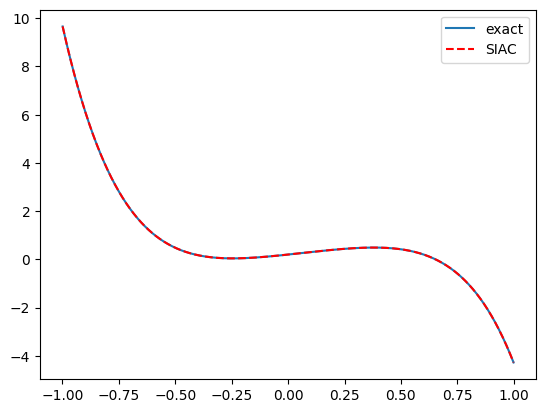

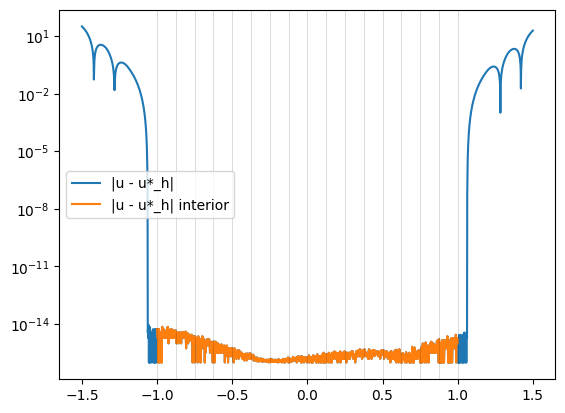

In [311]:
from src.siac_modal import grab_integrals, siac_cgam
moments = 4
BSorder = 3


u_siac_eval = eval_siac_1d_on_grid(
    x=grid_fine,
    coeffs=coeffs_1d,
    x_edges=xmesh,
    p=deg,
    moments=moments,
    BSorder=BSorder
)

halfker = int(np.ceil((moments + BSorder) / 2))

mask = (grid_fine > xleft + halfker*dx) & (grid_fine < xright - halfker*dx)

plt.plot(grid_fine[mask], u_exact_fine[mask], label="exact")
plt.plot(grid_fine[mask], u_siac_eval[mask], "r--", label="SIAC")
plt.legend()
plt.show()


# difference / error
eps = 1e-16
plt.semilogy(grid_fine, np.abs(u_exact_fine - u_siac_eval) + eps, label="|u - u*_h|")

plt.semilogy(grid_fine[mask], np.abs(u_exact_fine[mask] - u_siac_eval[mask]) + eps, label="|u - u*_h| interior")
for xe in xmesh[halfker:Kx - halfker+1]:
    plt.axvline(xe, color='k', linewidth=0.5, alpha=0.2)
plt.legend()
plt.show()


In [312]:
def l2_error_1d(u_exact, u_approx, x):
    err_sq = (u_exact - u_approx)**2
    return np.sqrt(np.trapezoid(err_sq, x))

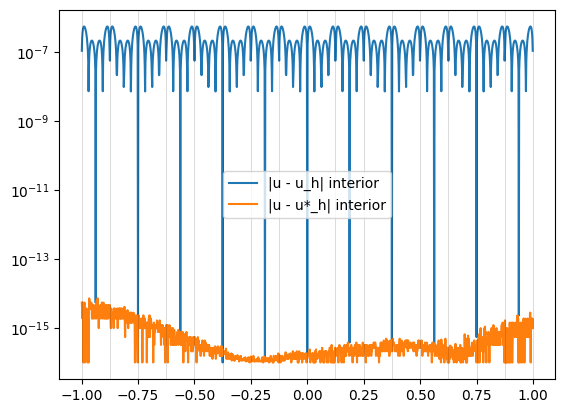

L2 error DG with p=4:            4.050113978378649e-07
L2 error siac with r=5, n=3:     1.6425110407317653e-15


In [313]:
# difference / error
eps = 1e-16

plt.semilogy(grid_fine[mask], np.abs(u_exact_fine[mask] - u_eval[mask]) + eps, label="|u - u_h| interior")
plt.semilogy(grid_fine[mask], np.abs(u_exact_fine[mask] - u_siac_eval[mask]) + eps, label="|u - u*_h| interior")
for xe in xmesh[halfker:Kx - halfker + 1]:
    plt.axvline(xe, color='k', linewidth=0.5, alpha=0.2)
plt.legend()
plt.show()

# L2 error
l2_dg = l2_error_1d(u_exact_fine[mask], u_eval[mask], grid_fine[mask])
l2_siac = l2_error_1d(u_exact_fine[mask], u_siac_eval[mask], grid_fine[mask])

print(f"L2 error DG with p={deg}:            {l2_dg}")
print(f"L2 error siac with r={moments+1}, n={BSorder}:     {l2_siac}")

In [314]:
def convergence_rates(h, err):
    h = np.asarray(h, dtype=float)
    err = np.asarray(err, dtype=float)

    rates = np.full(len(err), np.nan)
    for i in range(1, len(err)):
        rates[i] = np.log(err[i-1] / err[i]) / np.log(h[i-1] / h[i])
    return rates


def run_siac_convergence_1d(
    exact_func,
    xleft,
    xright,
    K_list,
    deg,
    moments,
    BSorder,
    n_fine=4001,
    add_noise=False,
    noise_scale_power=None,
):
    """
    Run convergence study for DG and SIAC in 1D.

    Parameters
    ----------
    exact_func : callable
        Exact function u(x).
    xleft, xright : float
        Domain endpoints.
    K_list : list[int]
        Numbers of elements to test, e.g. [12, 24, 48, 96].
    deg : int
        DG polynomial degree p.
    moments : int
        SIAC moments parameter passed to eval_siac_1d_on_grid.
    BSorder : int
        SIAC B-spline order passed to eval_siac_1d_on_grid.
    n_fine : int
        Number of fine-grid points for evaluation / L2 integration.
    add_noise : bool
        Whether to perturb nodal samples.
    noise_scale_power : int or None
        Noise size dx**noise_scale_power. If None and add_noise=True, uses deg+1.

    Returns
    -------
    results : dict
        Dictionary with h, errors, rates, etc.
    """
    order = deg + 1
    halfker = int(np.ceil((moments + BSorder) / 2))

    hs = []
    err_dg = []
    err_siac = []

    for Kx in K_list:
        dx = (xright - xleft) / Kx
        xmesh = np.linspace(xleft, xright, Kx + 1)

        # DG nodal locations per element
        Nodes = np.linspace(-1.0, 1.0, order)
        left_endpoints = xmesh[:-1]
        y = left_endpoints[:, None] + 0.5 * dx * (Nodes[None, :] + 1.0)

        Unode = exact_func(y)

        if add_noise:
            pw = deg + 1 if noise_scale_power is None else noise_scale_power
            sigma = dx**pw
            noise = np.random.randn(*Unode.shape) * sigma
            Unode = Unode + noise
            
            print(f"[noise] K={Kx}, dx={dx:.3e}, sigma={sigma:.3e} (dx^{pw})")
            rel_noise = np.linalg.norm(noise) / np.linalg.norm(Unode)
            print(f"[noise] K={Kx}, dx={dx:.3e}, sigma={sigma:.3e}, rel_noise={rel_noise:.3e}")

        # nodal -> modal
        coeffs_1d, nodes, V, Vinv = nodal_data_to_modal_1d(
            Unode,
            p=deg
        )

        # fine grid
        grid_fine = np.linspace(xleft, xright, n_fine)
        u_exact_fine = exact_func(grid_fine)

        # DG evaluation
        u_eval = eval_dg_modal_1d(
            x=grid_fine,
            coeffs=coeffs_1d,
            x_edges=xmesh,
            p=deg
        )

        # SIAC evaluation
        u_siac_eval = eval_siac_1d_on_grid(
            x=grid_fine,
            coeffs=coeffs_1d,
            x_edges=xmesh,
            p=deg,
            moments=moments,
            BSorder=BSorder
        )

        # interior mask: exclude boundary region affected by kernel support
        if 2 * halfker >= Kx:
            raise ValueError(
                f"Kx={Kx} is too small for halfker={halfker}. "
                "Need enough interior elements after trimming."
            )

        xL_int = xmesh[halfker]
        xR_int = xmesh[Kx - halfker]
        mask = (grid_fine >= xL_int) & (grid_fine <= xR_int)

        l2_dg = l2_error_1d(u_exact_fine[mask], u_eval[mask], grid_fine[mask])
        l2_siac = l2_error_1d(u_exact_fine[mask], u_siac_eval[mask], grid_fine[mask])

        hs.append(dx)
        err_dg.append(l2_dg)
        err_siac.append(l2_siac)

        print(f"K={Kx:4d}, h={dx:.4e}, L2(DG)={l2_dg:.4e}, L2(SIAC)={l2_siac:.4e}")

    hs = np.array(hs)
    err_dg = np.array(err_dg)
    err_siac = np.array(err_siac)

    rates_dg = convergence_rates(hs, err_dg)
    rates_siac = convergence_rates(hs, err_siac)

    return {
        "K": np.array(K_list),
        "h": hs,
        "err_dg": err_dg,
        "err_siac": err_siac,
        "rates_dg": rates_dg,
        "rates_siac": rates_siac,
        "deg": deg,
        "moments": moments,
        "BSorder": BSorder,
        "halfker": halfker,
    }


def print_convergence_table(results):
    K = results["K"]
    h = results["h"]
    err_dg = results["err_dg"]
    err_siac = results["err_siac"]
    rates_dg = results["rates_dg"]
    rates_siac = results["rates_siac"]

    print("\nConvergence table:")
    print(f"{'K':>6} {'h':>12} {'L2 DG':>14} {'rate DG':>10} {'L2 SIAC':>14} {'rate SIAC':>10}")
    print("-" * 72)
    for i in range(len(K)):
        rdg = "-" if np.isnan(rates_dg[i]) else f"{rates_dg[i]:.4f}"
        rsi = "-" if np.isnan(rates_siac[i]) else f"{rates_siac[i]:.4f}"
        print(f"{K[i]:6d} {h[i]:12.4e} {err_dg[i]:14.4e} {rdg:>10} {err_siac[i]:14.4e} {rsi:>10}")


def plot_convergence(results):
    h = results["h"]
    err_dg = results["err_dg"]
    err_siac = results["err_siac"]
    deg = results["deg"]
    moments = results["moments"]
    BSorder = results["BSorder"]

    plt.figure(figsize=(7, 5))
    plt.loglog(h, err_dg, 'o-', label=f"DG p={deg}")
    plt.loglog(h, err_siac, 's-', label=f"SIAC (moments={moments}, BSorder={BSorder})")
    # refernce
    h0 = h[0]
    err_dg0 = err_dg[0]
    err_siac0 = err_siac[0]
    offset = 10**(-0.3)   # slightly below (~factor 0.5)
    
    k_dg = deg + 1
    C_dg = offset * err_dg0 / (h0**k_dg)
    ref_dg = C_dg * h**k_dg

    k_siac = 2*deg + 1
    C_siac = offset * err_siac0 / (h0**k_siac)
    ref_siac = C_siac * h**k_siac
    
    plt.loglog(h, ref_dg, 'k-.', label=rf"$h^{{{k_dg}}}$")
    plt.loglog(h, ref_siac, 'k--', label=rf"$h^{{{k_siac}}}$")
    
    plt.gca().invert_xaxis()
    plt.xlabel("h")
    plt.ylabel(r"$L^2$ error")
    plt.title("1D DG / SIAC convergence")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

K=  16, h=1.5625e-01, L2(DG)=7.3373e-03, L2(SIAC)=2.1248e-02
K=  32, h=7.8125e-02, L2(DG)=1.2082e-03, L2(SIAC)=1.0381e-03
K=  64, h=3.9062e-02, L2(DG)=1.6557e-04, L2(SIAC)=3.3043e-05
K= 128, h=1.9531e-02, L2(DG)=2.1655e-05, L2(SIAC)=1.3051e-06
K= 256, h=9.7656e-03, L2(DG)=2.7149e-06, L2(SIAC)=7.0365e-08
K= 512, h=4.8828e-03, L2(DG)=3.3989e-07, L2(SIAC)=4.2392e-09

Convergence table:
     K            h          L2 DG    rate DG        L2 SIAC  rate SIAC
------------------------------------------------------------------------
    16   1.5625e-01     7.3373e-03          -     2.1248e-02          -
    32   7.8125e-02     1.2082e-03     2.6024     1.0381e-03     4.3553
    64   3.9062e-02     1.6557e-04     2.8673     3.3043e-05     4.9735
   128   1.9531e-02     2.1655e-05     2.9346     1.3051e-06     4.6621
   256   9.7656e-03     2.7149e-06     2.9957     7.0365e-08     4.2131
   512   4.8828e-03     3.3989e-07     2.9978     4.2392e-09     4.0530


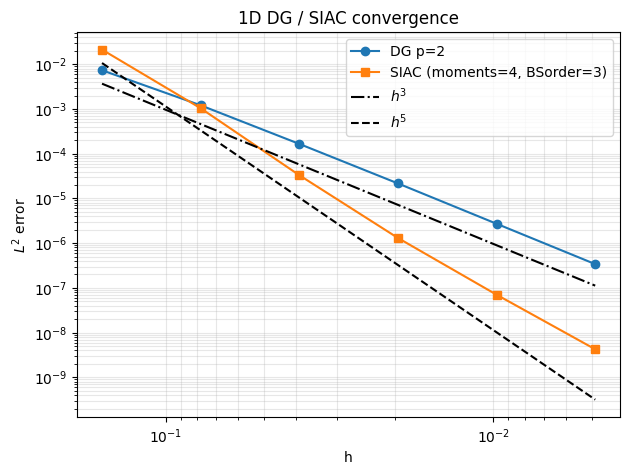

In [316]:
# Example exact function
# def exact_func(x):
#     return 3*x**3 + 0.5*x**2 + x + 0.2
def exact_func(x):
    return np.sin(2*np.pi*x) + 0.1*np.cos(5*np.pi*x)

xleft = -1.25
xright = 1.25

deg = 2
moments = 4
BSorder = 3


K_list = 16 * 2**np.arange(6)

results = run_siac_convergence_1d(
    exact_func=exact_func,
    xleft=xleft,
    xright=xright,
    K_list=K_list,
    deg=deg,
    moments=moments,
    BSorder=BSorder,
    n_fine=4001,
    add_noise=False,
)

print_convergence_table(results)
plot_convergence(results)